In [1]:
!pip install openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Importing libraries & datset
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel('Dataset for Data Analytics.xlsx')

**# Cleaning the Dataset**

In [3]:
#Exploring the data
df.shape          
df.head()         
df.info()         
df.describe()     
df.isnull().sum() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [4]:
#handling missing values
df['CouponCode'] = df['CouponCode'].fillna('None')
print(df['CouponCode'].isnull().sum())

0


In [5]:
#checking & handling duplicates
print(df.duplicated().sum())
print(df['OrderID'].duplicated().sum())
df = df.drop_duplicates()
df = df.drop_duplicates(subset='OrderID')

0
0


In [6]:
#fixing date format
df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = df['Date'].dt.strftime('%Y-%m-%d')
print(df['Date'].head())

0    2023-01-04
1    2024-08-23
2    2024-02-27
3    2023-10-15
4    2025-05-08
Name: Date, dtype: object


In [7]:
#decimal places
df['UnitPrice'] = df['UnitPrice'].round(2)
df['TotalPrice'] = df['TotalPrice'].round(2)

In [8]:
#verifying totalprice calculation
df['Check'] = (df['Quantity'] * df['UnitPrice']).round(2)
mismatches = df[abs(df['Check'] - df['TotalPrice']) > 0.01]
print("Mismatches found:", len(mismatches))
df['TotalPrice'] = df['Check']
df = df.drop(columns=['Check'])

Mismatches found: 0


In [9]:
#final check
print("Missing values:\n", df.isnull().sum())
print("Duplicate OrderIDs:", df['OrderID'].duplicated().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Total records:", len(df))

Missing values:
 OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64
Duplicate OrderIDs: 0
Duplicate rows: 0
Total records: 1200


In [10]:
#saving cleaned dataset
df.to_excel('Cleaned_Dataset_Python.xlsx', index=False)
print("File saved successfully!")

File saved successfully!


**# Cleaning the Dataset**

In [11]:
#descriptive statistics for numeric columns
print(df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].describe())
print("\nMean TotalPrice:", df['TotalPrice'].mean().round(2))
print("Median TotalPrice:", df['TotalPrice'].median().round(2))


          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000

Mean TotalPrice: 1053.97
Median TotalPrice: 823.62


In [13]:
#orders per category
print("Orders by Product:\n", df['Product'].value_counts())
print("\nOrders by OrderStatus:\n", df['OrderStatus'].value_counts())
print("\nOrders by ReferralSource:\n", df['ReferralSource'].value_counts())
print("\nOrders by PaymentMethod:\n", df['PaymentMethod'].value_counts())

Orders by Product:
 Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

Orders by OrderStatus:
 OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

Orders by ReferralSource:
 ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

Orders by PaymentMethod:
 PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


In [14]:
#total and average revenue by product
print(df.groupby('Product')['TotalPrice'].agg(['sum', 'mean', 'count']).round(2))

print("\nRevenue by ReferralSource:")
print(df.groupby('ReferralSource')['TotalPrice'].agg(['sum', 'mean']).round(2))

               sum     mean  count
Product                           
Chair    195620.11  1098.99    178
Desk     167459.93   985.06    170
Laptop   192126.56  1110.56    173
Monitor  175651.41  1077.62    163
Phone    151722.39   972.58    156
Printer  195612.61  1080.73    181
Tablet   186568.95  1042.28    179

Revenue by ReferralSource:
                      sum     mean
ReferralSource                    
Email           261808.55  1047.23
Facebook        250410.90  1098.29
Google          250441.48  1039.18
Instagram       275285.45  1062.88
Referral        226815.58  1021.69


In [15]:
# Convert Date back to datetime first
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
df['Year'] = df['Date'].dt.year

print("Revenue by Year:")
print(df.groupby('Year')['TotalPrice'].sum().round(2))

print("\nMonthly Revenue:")
print(df.groupby('Month')['TotalPrice'].sum())

Revenue by Year:
Year
2023    552643.24
2024    480235.87
2025    231882.85
Name: TotalPrice, dtype: float64

Monthly Revenue:
Month
2023-01    56685.75
2023-02    40117.66
2023-03    48609.37
2023-04    27751.71
2023-05    63836.84
2023-06    49500.19
2023-07    42820.66
2023-08    54352.14
2023-09    29526.67
2023-10    52607.85
2023-11    43079.67
2023-12    43754.73
2024-01    38528.08
2024-02    36909.57
2024-03    36030.90
2024-04    49613.14
2024-05    27909.11
2024-06    68068.54
2024-07    42963.98
2024-08    31991.07
2024-09    39794.98
2024-10    37226.97
2024-11    32413.76
2024-12    38785.77
2025-01    29099.40
2025-02    35317.55
2025-03    39200.66
2025-04    31821.20
2025-05    43396.64
2025-06    53047.40
Freq: M, Name: TotalPrice, dtype: float64


In [16]:
#outlier detection using IQR method
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['TotalPrice'] < lower) | (df['TotalPrice'] > upper)]
print(f"Outliers found: {len(outliers)}")
print(outliers[['OrderID', 'Product', 'TotalPrice']])

Outliers found: 8
        OrderID  Product  TotalPrice
107   ORD200107  Printer     3353.75
326   ORD200326   Laptop     3352.40
328   ORD200328   Tablet     3370.20
469   ORD200469    Chair     3384.90
632   ORD200632   Laptop     3390.80
789   ORD200789   Tablet     3456.40
1065  ORD201065  Printer     3334.00
1122  ORD201122  Monitor     3390.95


In [17]:
#correlation analysis
corr = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].corr().round(3)
print("Correlation Matrix:")
print(corr)

Correlation Matrix:
             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity        1.000      0.015        0.650       0.615
UnitPrice       0.015      1.000        0.001       0.717
ItemsInCart     0.650      0.001        1.000       0.393
TotalPrice      0.615      0.717        0.393       1.000


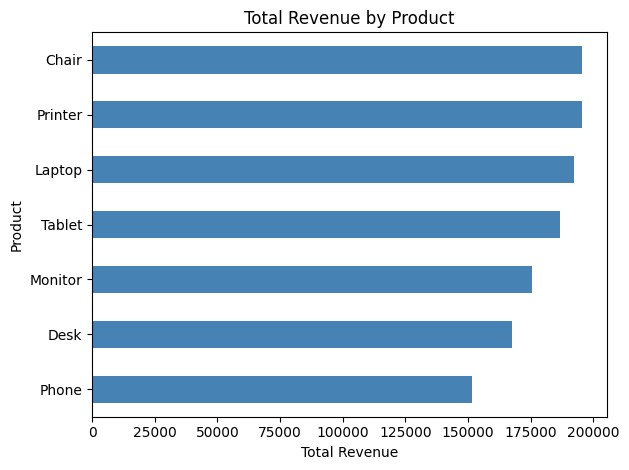

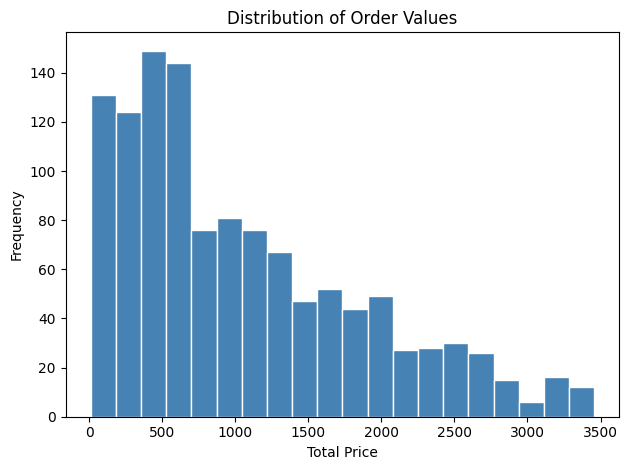

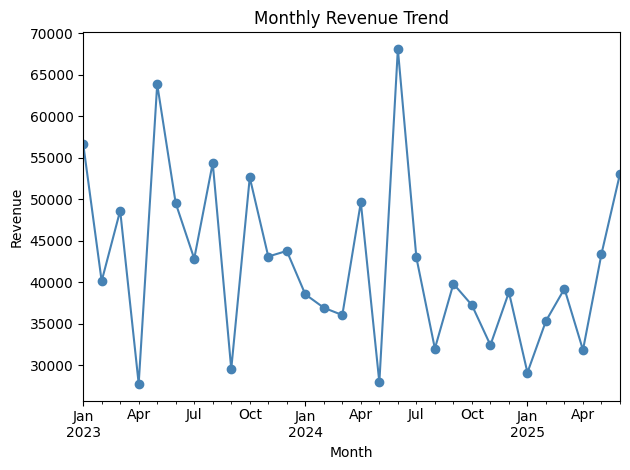

In [18]:
#revenue by Product
df.groupby('Product')['TotalPrice'].sum().sort_values().plot(kind='barh', title='Total Revenue by Product', color='steelblue')
plt.xlabel('Total Revenue')
plt.tight_layout()
plt.show()

#order Value Distribution
df['TotalPrice'].plot(kind='hist', bins=20, title='Distribution of Order Values', color='steelblue', edgecolor='white')
plt.xlabel('Total Price')
plt.tight_layout()
plt.show()

#monthly Revenue Trend
df.groupby('Month')['TotalPrice'].sum().plot(kind='line', title='Monthly Revenue Trend', color='steelblue', marker='o')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()


In [19]:
#Log of changes made

eda_log = pd.DataFrame([
    ['CR006', 'TotalPrice', 'EDA - Descriptive Stats', 'Calculated mean, median, std, quartiles', 'Mean=$1053.97, Median=$823.62', 'Completed'],
    ['CR007', 'Multiple', 'EDA - Categorical Analysis', 'Counted orders by Product, Status, Source', 'All 7 products, 5 statuses analyzed', 'Completed'],
    ['CR008', 'TotalPrice', 'EDA - Outlier Detection', 'Applied IQR method', '8 high-value outliers found', 'Completed'],
    ['CR009', 'Multiple', 'EDA - Correlation Analysis', 'Pearson correlation matrix', 'UnitPrice strongest predictor (r=0.717)', 'Completed'],
    ['CR010', 'Date', 'EDA - Trend Analysis', 'Grouped revenue by month and year', 'Peak revenue in 2023', 'Completed'],
], columns=['Change ID', 'Column', 'Issue', 'Action', 'Impact', 'Status'])

full_log = pd.concat([change_log, eda_log], ignore_index=True)

with pd.ExcelWriter('EDA_Final_Dataset.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Cleaned_Data', index=False)
    full_log.to_excel(writer, sheet_name='Change_Log', index=False)

print("EDA complete! File saved as EDA_Final_Dataset.xlsx")

EDA complete! File saved as EDA_Final_Dataset.xlsx
